# 01 – Exploratory Data Analysis (EDA)

## Notebook Contents
- Descriptive analysis of the dataset
- Analysis of the price distribution

In [1]:
# Imports und Daten laden

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/sample_listings.csv")
print (f"Datensatz mit {df.shape[0]} Zeilen und {df.shape[1]} Spalten geladen.")

Datensatz mit 10000 Zeilen und 9 Spalten geladen.


In [2]:
# Daten anzeigen

df.head()

,price,neighbourhood,room_type,minimum_nights,number_of_reviews,review_scores_rating,amenities,latitude,longitude
0,205.0,I Centro Storico,Entire home/apt,1,59,4.68,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",41.877946,12.473666
1,149.0,VIII Appia Antica,Entire home/apt,3,13,5.00,"[""Hangers"", ""Carbon monoxide alarm"", ""Clothing...",41.860463,12.483244
2,67.0,XIII Aurelia,Entire home/apt,1,94,4.95,"[""Heating"", ""Free parking on premises"", ""Clean...",41.894668,12.447176
3,102.0,I Centro Storico,Private room,5,435,4.80,"[""Air conditioning"", ""Hangers"", ""Wifi"", ""Host ...",41.894140,12.506500
4,140.0,I Centro Storico,Entire home/apt,2,54,4.76,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",41.912990,12.455640


In [3]:
# Deskriptive Statistik

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,10000.0,NaN,NaN,NaN,153.346,84.249525,23.0,94.0,131.0,186.0,500.0
neighbourhood,10000,15,I Centro Storico,4927,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,10000,4,Entire home/apt,7851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minimum_nights,10000.0,NaN,NaN,NaN,1.8953,1.337878,1.0,1.0,2.0,2.0,30.0
number_of_reviews,10000.0,NaN,NaN,NaN,65.1311,103.47204,0.0,4.0,24.0,79.0,1244.0
review_scores_rating,10000.0,NaN,NaN,NaN,4.793874,0.276718,1.0,4.74,4.86,4.95,5.0
amenities,10000,9796,"[""Air conditioning"", ""Lock on bedroom door"", ""...",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,10000.0,NaN,NaN,NaN,41.891067,0.03501,41.65727,41.883249,41.89621,41.90621,42.120448
longitude,10000.0,NaN,NaN,NaN,12.479489,0.04911,12.25835,12.458445,12.476935,12.505482,12.709461


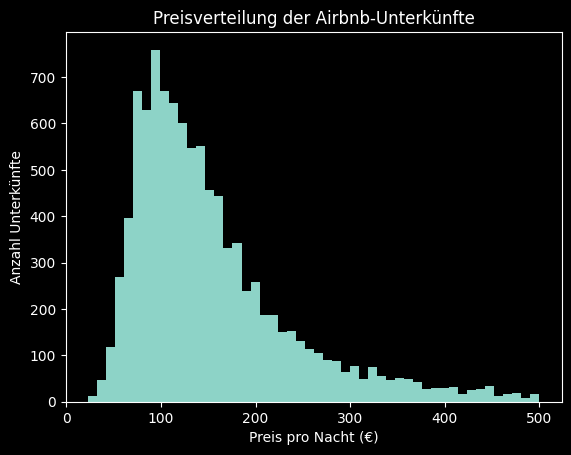

In [4]:
# Preisverteilung visualisieren

plt.hist(df["price"], bins=50)
plt.xlabel("Preis pro Nacht (€)")
plt.ylabel("Anzahl Unterkünfte")
plt.title("Preisverteilung der Airbnb-Unterkünfte")
plt.show()


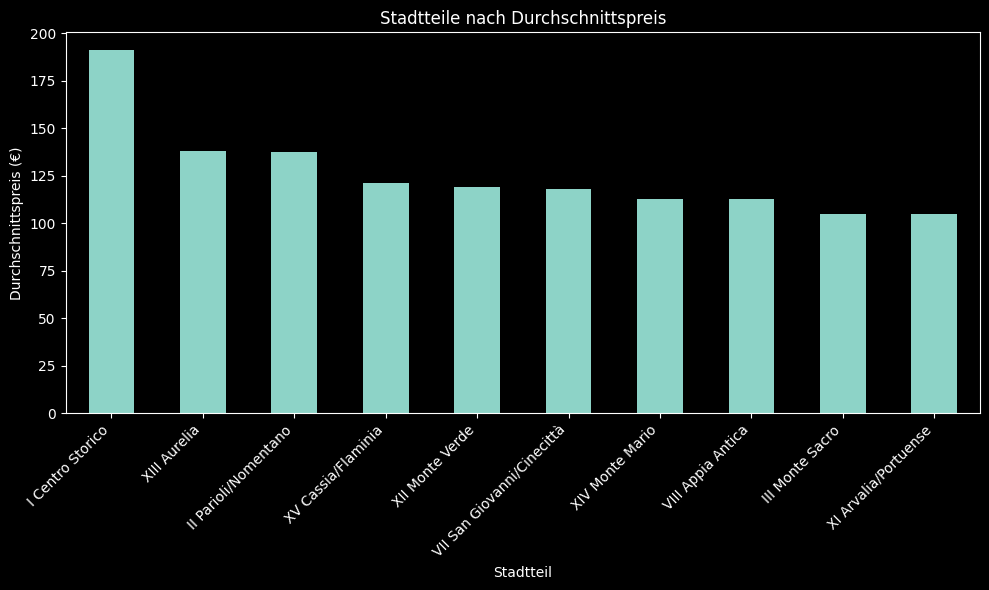

In [5]:
# Teuersten Stadtteile nach Durchschnittspreis

top_neigh = (
    df.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

top_neigh.plot(kind="bar", ax=ax)

ax.set_ylabel("Durchschnittspreis (€)")
ax.set_xlabel("Stadtteil")
ax.set_title("Stadtteile nach Durchschnittspreis")

plt.xticks(rotation=45, ha="right")
fig.tight_layout()

plt.show()



## Conclusion

### Dataset Overview
- 10,000 rows
- 9 columns
  - 1 target variable (`price`)
  - 2 categorical features (`amenities`, `neighbourhood`)
  - 7 numerical features

### Key Insights on Price Distribution
- The average nightly price is approximately €150, while the median price is around €130
- The most expensive listings are located in the city center (Centro Storico)
- The price distribution is right-skewed